count    968.000000
mean       3.076678
std        1.860773
min        0.835415
25%        1.877740
50%        2.689619
75%        3.537081
max       18.100110
Name: total_execution_time_min, dtype: float64
count    32.000000
mean     14.030952
std       6.279665
min       5.465570
25%       9.697029
50%      11.851226
75%      17.026284
max      31.943698
Name: total_execution_time_min, dtype: float64


/tmp/ipykernel_2035/1567770352.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="category", y="total_execution_time_min", data=plot_df, palette="Set2", cut=0, order=category_order)


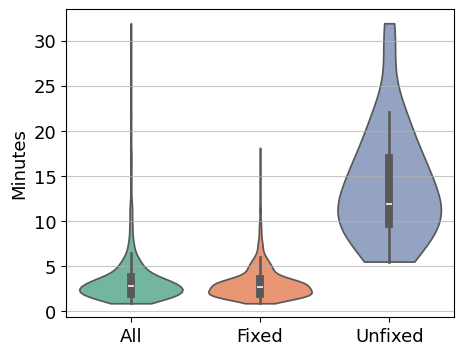

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


def nano_to_second(time_in_nano: float):
    return round(time_in_nano / 1_000_000_000, 4)


### Time plot for fixed/unfixed


evaluation_results_df = pd.read_csv("../evaluation_results/evaluation_results_extended.csv")


evaluation_results_df["total_execution_time_min"] = nano_to_second(
    evaluation_results_df["executionTimeClassification"] +
    evaluation_results_df["executionTimeFixTP"] +
    evaluation_results_df["executionTimeFixFP"]
) / 60


print(evaluation_results_df[evaluation_results_df["plausibleFix"]]["total_execution_time_min"].describe())
print(evaluation_results_df[~evaluation_results_df["plausibleFix"]]["total_execution_time_min"].describe())


evaluation_results_df["category"] = np.where(
    evaluation_results_df["plausibleFix"], "Fixed", "Unfixed"
)

category_order = ["All", "Fixed", "Unfixed"]

all_df = evaluation_results_df.copy()
all_df["category"] = "All"

plot_df = pd.concat([all_df, evaluation_results_df], ignore_index=True)





# Create violin plot
plt.figure(figsize=(5, 4))
plt.rcParams["font.size"] = 13
# Use TruType fonts instead of Type 3
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

sns.violinplot(x="category", y="total_execution_time_min", data=plot_df, palette="Set2", cut=0, order=category_order)

plt.ylabel("Minutes")
plt.xlabel("")
plt.grid(axis='y', alpha=0.7)
# Make figure and axes backgrounds transparent for PNG export
fig = plt.gcf()
fig.patch.set_alpha(0)
plt.savefig("../evaluation_results/plots/cca_time_fixed_unfixed.png", dpi=300, transparent=True)


plt.savefig("../evaluation_results/plots/cca_time_fixed_unfixed.pdf")
plt.show()

count    520.000000
mean       2.751736
std        1.658856
min        0.841345
25%        1.753195
50%        2.363028
75%        3.232715
max       17.634856
Name: total_execution_time_min, dtype: float64
count    444.000000
mean       3.913648
std        3.481080
min        0.835415
25%        2.142676
50%        2.989335
75%        4.349892
max       31.943698
Name: total_execution_time_min, dtype: float64
count    36.000000
mean      7.184789
std       4.278289
min       1.754181
25%       3.357162
50%       6.308871
75%      10.755421
max      17.093150
Name: total_execution_time_min, dtype: float64


/tmp/ipykernel_3788/425896177.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="category", y="total_execution_time_min", data=plot_df, palette="Set2", cut=0, order=category_order )


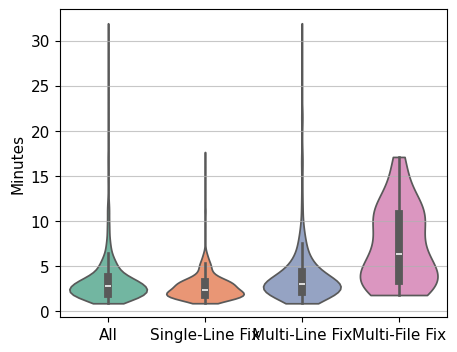

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np





### Time plot for single line / multi line / multi file


evaluation_results_df = pd.read_csv("../evaluation_results/evaluation_results_extended.csv")


evaluation_results_df["total_execution_time_min"] = (
    evaluation_results_df["executionTimeClassification"] +
    evaluation_results_df["executionTimeFixTP"] +
    evaluation_results_df["executionTimeFixFP"]
) / 1_000_000_000 / 60

evaluation_results_df["total_execution_time_min"] = evaluation_results_df["total_execution_time_min"].clip(lower=0)




evaluation_results_df["category"] = evaluation_results_df["fixComplexity"].map({
    "Single Line": "Single-Line Fix",
    "Multi Line": "Multi-Line Fix",
    "Multi File": "Multi-File Fix"
})

print(evaluation_results_df[evaluation_results_df["fixComplexity"] == "Single Line"]["total_execution_time_min"].describe())
print(evaluation_results_df[evaluation_results_df["fixComplexity"] == "Multi Line"]["total_execution_time_min"].describe())
print(evaluation_results_df[evaluation_results_df["fixComplexity"] == "Multi File"]["total_execution_time_min"].describe())

category_order = ["All", "Single-Line Fix", "Multi-Line Fix", "Multi-File Fix"]


all_df = evaluation_results_df.copy()
all_df["category"] = "All"

plot_df = pd.concat([all_df, evaluation_results_df], ignore_index=True)





# Create violin plot
plt.figure(figsize=(5, 4))
# Use TruType fonts instead of Type 3
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

sns.violinplot(x="category", y="total_execution_time_min", data=plot_df, palette="Set2", cut=0, order=category_order )

plt.ylabel("Minutes")
plt.xlabel("")
plt.grid(axis='y', alpha=0.7)
plt.savefig("../evaluation_results/plots/cca_time_per_fix_complexity.pdf")
plt.show()

count    696.000000
mean       3.789710
std        3.282891
min        0.835415
25%        2.040868
50%        2.931794
75%        4.142932
max       31.943698
Name: total_execution_time_min, dtype: float64
count    304.000000
mean       2.597291
std        1.280154
min        0.841345
25%        1.685810
50%        2.256398
75%        3.198614
max       10.718918
Name: total_execution_time_min, dtype: float64


/tmp/ipykernel_3788/3711607527.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="category", y="total_execution_time_min", data=plot_df, palette="Set2", cut=0, order=category_order)


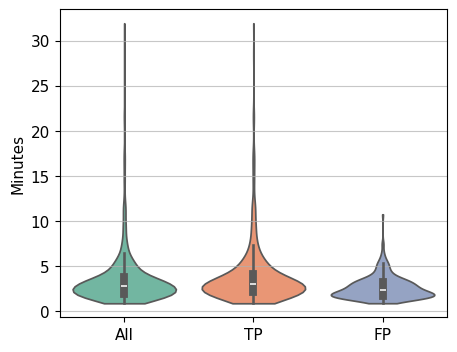

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


def nano_to_second(time_in_nano: float):
    return round(time_in_nano / 1_000_000_000, 4)


### Time plot for TP/FP


evaluation_results_df = pd.read_csv("../evaluation_results/evaluation_results_extended.csv")


evaluation_results_df["total_execution_time_min"] = nano_to_second(
    evaluation_results_df["executionTimeClassification"] +
    evaluation_results_df["executionTimeFixTP"] +
    evaluation_results_df["executionTimeFixFP"]
) / 60


print(evaluation_results_df[evaluation_results_df["classification"] == "TP"]["total_execution_time_min"].describe())
print(evaluation_results_df[evaluation_results_df["classification"] == "FP"]["total_execution_time_min"].describe())


evaluation_results_df["category"] = np.where(
    evaluation_results_df["classification"] == "TP", "TP", "FP"
)

category_order = ["All", "TP", "FP"]

all_df = evaluation_results_df.copy()
all_df["category"] = "All"

plot_df = pd.concat([all_df, evaluation_results_df], ignore_index=True)





# Create violin plot
plt.figure(figsize=(5, 4))
# Use TruType fonts instead of Type 3
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

sns.violinplot(x="category", y="total_execution_time_min", data=plot_df, palette="Set2", cut=0, order=category_order)

plt.ylabel("Minutes")
plt.xlabel("")
plt.grid(axis='y', alpha=0.7)
plt.savefig("../evaluation_results/plots/cca_time_tp_fp.pdf")
plt.show()

/tmp/ipykernel_3788/4228907758.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="category", y="execution_time_min", data=plot_df, palette="Set2", cut=0, order=category_order)


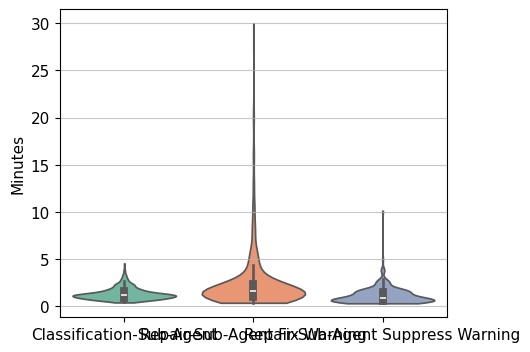

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


def nano_to_second(time_in_nano: float):
    return round(time_in_nano / 1_000_000_000, 4)


### Time plot per sub-agent


evaluation_results_df = pd.read_csv("../evaluation_results/evaluation_results_extended.csv")


evaluation_results_df["total_execution_time_min"] = nano_to_second(
    evaluation_results_df["executionTimeClassification"] +
    evaluation_results_df["executionTimeFixTP"] +
    evaluation_results_df["executionTimeFixFP"]
) / 60




evaluation_results_df["category"] = np.where(
    evaluation_results_df["classification"] == "TP", "TP", "FP"
)

category_order = ["Classification-Sub-Agent", "Repair-Sub-Agent Fix Warning", "Repair-Sub-Agent Suppress Warning"]

classification_sec = evaluation_results_df.copy()
classification_sec["category"] = "Classification-Sub-Agent"
classification_sec["execution_time_min"] = nano_to_second(classification_sec["executionTimeClassification"]) / 60

repair_sec = evaluation_results_df.copy()
repair_sec["category"] = np.where(
    repair_sec["classification"] == "TP", "Repair-Sub-Agent Fix Warning", "Repair-Sub-Agent Suppress Warning"
)
repair_sec["execution_time_min"] = np.where(
    repair_sec["classification"] == "TP", nano_to_second(repair_sec["executionTimeFixTP"]) / 60, nano_to_second(repair_sec["executionTimeFixFP"]) / 60
) 

plot_df = pd.concat([classification_sec, repair_sec], ignore_index=True)




# Create violin plot
plt.figure(figsize=(5, 4))
# Use TruType fonts instead of Type 3
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

sns.violinplot(x="category", y="execution_time_min", data=plot_df, palette="Set2", cut=0, order=category_order)

plt.ylabel("Minutes")
plt.xlabel("")
plt.grid(axis='y', alpha=0.7)
plt.savefig("../evaluation_results/plots/cca_time_per_sub_agent.pdf")
plt.show()

/tmp/ipykernel_3788/343418493.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="category", y="total_token_consumption_in_k", data=plot_df, palette="Set2", cut=0, order=category_order, ax=ax1)
/tmp/ipykernel_3788/343418493.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="category", y="total_cost", data=plot_df, palette="Set3", cut=0, order=category_order, ax=ax2)


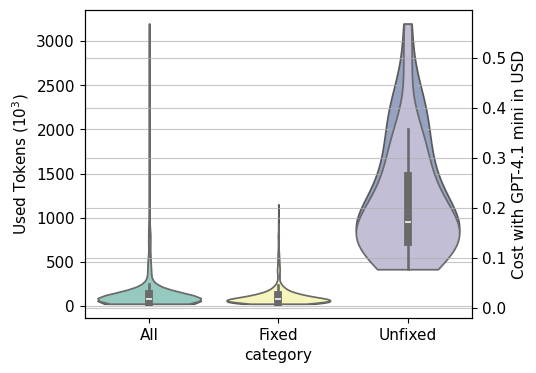

In [5]:


import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np




### Cost and token consumption fixed vs. not fixed

## PROBLEM: Putting both total token consuption and cost into the same plot leads to ambiguosly overlapping plots
#  as the same number of aggregated tokens does not imply the same cost. 
# Input tokens are less expensive than output tokens and cached input is even cheeper.
# In RepairAgent this problem existed in the plot too but was less visible
# => Keep it (would need a legend to know what is what), or do separate plots, or only one of both plots?


evaluation_results_df = pd.read_csv("../evaluation_results/evaluation_results_extended.csv")


evaluation_results_df["total_token_consumption_in_k"] =   (evaluation_results_df["tokensInputUncachedClassification"] +
    evaluation_results_df["tokensInputCachedClassification"] +
    evaluation_results_df["tokensOutputClassification"] + 

    evaluation_results_df["tokensInputUncachedFixTP"] +
    evaluation_results_df["tokensInputCachedFixTP"] +
    evaluation_results_df["tokensOutputFixTP"] + 

    evaluation_results_df["tokensInputUncachedFixFP"] +
    evaluation_results_df["tokensInputCachedFixFP"] +
    evaluation_results_df["tokensOutputFixFP"]) / 1000

evaluation_results_df["total_cost"] = (evaluation_results_df["costClassification"] +
    evaluation_results_df["costFixTP"] +
    evaluation_results_df["costFixFP"])



evaluation_results_df["category"] = np.where(
    evaluation_results_df["plausibleFix"], "Fixed", "Unfixed"
)

category_order = ["All", "Fixed", "Unfixed"]

all_df = evaluation_results_df.copy()
all_df["category"] = "All"

plot_df = pd.concat([all_df, evaluation_results_df], ignore_index=True)



# Create violin plot
plt.figure(figsize=(5, 4))
# Use TruType fonts instead of Type 3
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

ax1 = plt.gca()
sns.violinplot(x="category", y="total_token_consumption_in_k", data=plot_df, palette="Set2", cut=0, order=category_order, ax=ax1)
ax1.set_ylabel("Used Tokens ($10^3$)")

ax2 = ax1.twinx()
sns.violinplot(x="category", y="total_cost", data=plot_df, palette="Set3", cut=0, order=category_order, ax=ax2)
ax2.set_ylabel("Cost with GPT-4.1 mini in USD")

plt.xlabel("")
ax1.grid(axis='y', alpha=0.7)
ax2.grid(axis='y', alpha=0.7)
plt.savefig("../evaluation_results/plots/cca_cost_and_tokens_fixed_unfixed.pdf")
plt.show()

/tmp/ipykernel_3788/2520436375.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="category", y="total_token_consumption_in_k", data=plot_df, palette="Set2", cut=0, order=category_order)


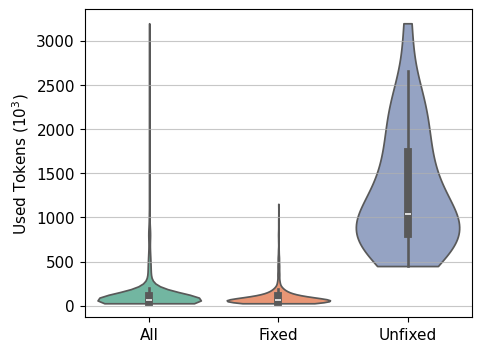

In [6]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np




### Only token consumption fixed vs. not fixed


evaluation_results_df = pd.read_csv("../evaluation_results/evaluation_results_extended.csv")


evaluation_results_df["total_token_consumption_in_k"] =   (evaluation_results_df["tokensInputUncachedClassification"] +
    evaluation_results_df["tokensInputCachedClassification"] +
    evaluation_results_df["tokensOutputClassification"] + 

    evaluation_results_df["tokensInputUncachedFixTP"] +
    evaluation_results_df["tokensInputCachedFixTP"] +
    evaluation_results_df["tokensOutputFixTP"] + 

    evaluation_results_df["tokensInputUncachedFixFP"] +
    evaluation_results_df["tokensInputCachedFixFP"] +
    evaluation_results_df["tokensOutputFixFP"]) / 1000




evaluation_results_df["category"] = np.where(
    evaluation_results_df["plausibleFix"], "Fixed", "Unfixed"
)

category_order = ["All", "Fixed", "Unfixed"]

all_df = evaluation_results_df.copy()
all_df["category"] = "All"

plot_df = pd.concat([all_df, evaluation_results_df], ignore_index=True)



# Create violin plot
plt.figure(figsize=(5, 4))
# Use TruType fonts instead of Type 3
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

sns.violinplot(x="category", y="total_token_consumption_in_k", data=plot_df, palette="Set2", cut=0, order=category_order)
plt.ylabel("Used Tokens ($10^3$)")


plt.xlabel("")
plt.grid(axis='y', alpha=0.7)
plt.savefig("../evaluation_results/plots/cca_only_tokens_fixed_unfixed.pdf")
plt.show()

count    968.000000
mean       0.022913
std        0.018595
min        0.007720
25%        0.012893
50%        0.017415
75%        0.025743
max        0.168988
Name: total_cost, dtype: float64
count    32.000000
mean      0.210104
std       0.113668
min       0.076833
25%       0.131208
50%       0.171462
75%       0.263038
max       0.568657
Name: total_cost, dtype: float64


/tmp/ipykernel_2035/1150321673.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="category", y="total_cost", data=plot_df, palette="Set2", cut=0, order=category_order)


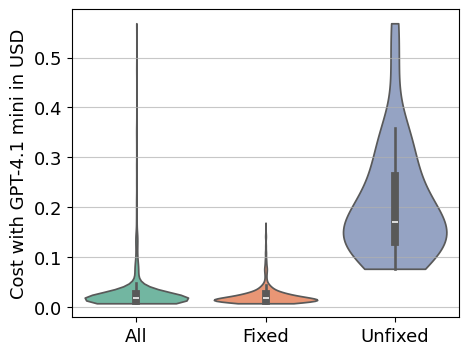

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np




### Only Cost fixed vs. not fixed


evaluation_results_df = pd.read_csv("../evaluation_results/evaluation_results_extended.csv")



evaluation_results_df["total_cost"] = (evaluation_results_df["costClassification"] +
    evaluation_results_df["costFixTP"] +
    evaluation_results_df["costFixFP"])



evaluation_results_df["category"] = np.where(
    evaluation_results_df["plausibleFix"], "Fixed", "Unfixed"
)

print(evaluation_results_df[evaluation_results_df["plausibleFix"]]["total_cost"].describe())
print(evaluation_results_df[~evaluation_results_df["plausibleFix"]]["total_cost"].describe())

category_order = ["All", "Fixed", "Unfixed"]

all_df = evaluation_results_df.copy()
all_df["category"] = "All"

plot_df = pd.concat([all_df, evaluation_results_df], ignore_index=True)



# Create violin plot
plt.figure(figsize=(5, 4))

plt.rcParams["font.size"] = 13
# Use TruType fonts instead of Type 3
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

sns.violinplot(x="category", y="total_cost", data=plot_df, palette="Set2", cut=0, order=category_order)
plt.ylabel("Cost with GPT-4.1 mini in USD")

plt.xlabel("")
plt.grid(axis='y', alpha=0.7)
# Make figure and axes backgrounds transparent for PNG export
fig = plt.gcf()
fig.patch.set_alpha(0)

plt.savefig("../evaluation_results/plots/cca_only_cost_fixed_unfixed.png", dpi=300, transparent=True)
plt.savefig("../evaluation_results/plots/cca_only_cost_fixed_unfixed.pdf")
plt.show()

/tmp/ipykernel_3788/1064283011.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="category", y="iterations", data=plot_df, palette="Set2", cut=0, order=category_order)


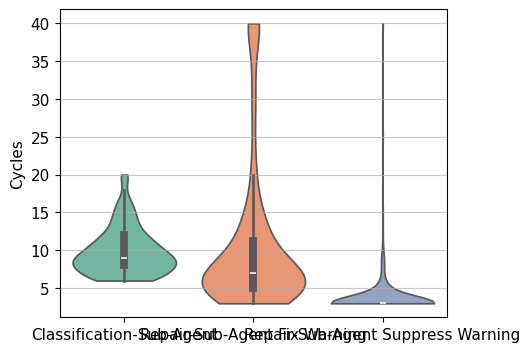

In [8]:




import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np




### Iterations per sub-agent


evaluation_results_df = pd.read_csv("../evaluation_results/evaluation_results_extended.csv")






evaluation_results_df["category"] = np.where(
    evaluation_results_df["classification"] == "TP", "TP", "FP"
)

category_order = ["Classification-Sub-Agent", "Repair-Sub-Agent Fix Warning", "Repair-Sub-Agent Suppress Warning"]

classification_sec = evaluation_results_df.copy()
classification_sec["category"] = "Classification-Sub-Agent"
classification_sec["iterations"] = classification_sec["iterationsClassification"]

repair_sec = evaluation_results_df.copy()
repair_sec["category"] = np.where(
    repair_sec["classification"] == "TP", "Repair-Sub-Agent Fix Warning", "Repair-Sub-Agent Suppress Warning"
)
repair_sec["iterations"] = np.where(
    repair_sec["classification"] == "TP", repair_sec["iterationsFixTP"], repair_sec["iterationsFixFP"]) 

plot_df = pd.concat([classification_sec, repair_sec], ignore_index=True)




# Create violin plot
plt.figure(figsize=(5, 4))
# Use TruType fonts instead of Type 3
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

sns.violinplot(x="category", y="iterations", data=plot_df, palette="Set2", cut=0, order=category_order)

plt.ylabel("Cycles")
plt.xlabel("")
plt.grid(axis='y', alpha=0.7)
plt.savefig("../evaluation_results/plots/cca_iterations_per_sub_agent.pdf")
plt.show()

count    968.000000
mean       7.501033
std        6.724909
min        3.000000
25%        3.000000
50%        5.000000
75%        8.000000
max       40.000000
Name: iterationsRepair, dtype: float64
count    32.0
mean     40.0
std       0.0
min      40.0
25%      40.0
50%      40.0
75%      40.0
max      40.0
Name: iterationsRepair, dtype: float64


/tmp/ipykernel_3788/871816579.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="category", y="iterations", data=plot_df, palette="Set2", cut=0, order=category_order)


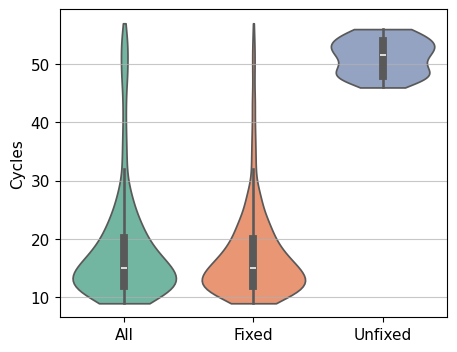

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np




### Iterations fixed vs. not fixed (not very meaningful as unfixed will always have x + 40 cycles by design)


evaluation_results_df = pd.read_csv("../evaluation_results/evaluation_results_extended.csv")



evaluation_results_df["iterationsRepair"] = np.where(
    evaluation_results_df["classification"] == "TP", (evaluation_results_df["iterationsFixTP"]), 
    (evaluation_results_df["iterationsFixFP"])) 

evaluation_results_df["iterations"]  = (evaluation_results_df["iterationsClassification"]  + evaluation_results_df["iterationsRepair"] )

evaluation_results_df["category"] = np.where(
    evaluation_results_df["plausibleFix"], "Fixed", "Unfixed"
)

print(evaluation_results_df[evaluation_results_df["category"] == "Fixed"]["iterationsRepair"].describe())
print(evaluation_results_df[evaluation_results_df["category"] == "Unfixed"]["iterationsRepair"].describe())

category_order = ["All", "Fixed", "Unfixed"]

all_df = evaluation_results_df.copy()
all_df["category"] = "All"

plot_df = pd.concat([all_df, evaluation_results_df], ignore_index=True)



# Create violin plot
plt.figure(figsize=(5, 4))

# Use TruType fonts instead of Type 3
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

sns.violinplot(x="category", y="iterations", data=plot_df, palette="Set2", cut=0, order=category_order)
plt.ylabel("Cycles")

plt.xlabel("")
plt.grid(axis='y', alpha=0.7)
plt.savefig("../evaluation_results/plots/cca_iterations_fixed_unfixed.pdf")
plt.show()